In [1]:
import os
import pandas as pd
import numpy as np
import re 
import matplotlib.pyplot as plt
import seaborn as sns
import calendar
from datetime import datetime, timedelta
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap

# --- Configuration ---
path_to_scenarios   = '/home/abhis/india_power/scenarios'
path_to_save_images = '/home/abhis/india_power/images'
path_to_save_images = '/home/abhis/india_power/images'
path_to_csvs        = '/home/abhis/india_power/gridpath_india_viz/csvs'
# scenario_names = ['iced_2050_cc_1','iced_2050_cc_2','iced_2050_cc_3'] # Example: Explicit list
# scenario_names = ['pier_mid_ra_2040_1','pier_mid_ra_2040_2','pier_mid_ra_2040_3'] # Example: Explicit list

tech_labels_ = pd.read_csv(path_to_csvs + '/technology_labels.csv') 
scenarios_   = pd.read_csv(path_to_csvs + '/ra-scenario_labels.csv')

# Load and processing system load timepoints

In [2]:
# Load and processing system load timepoints
def _processing_system_load_timepoints(scenarios_):

    dfs_ = []
    for scenario, path_to_scenarios in zip(scenarios_['scenario'], scenarios_['path']):
        path_to_scenario = os.path.join(path_to_scenarios, scenario)

        for dirpath, dirnames, filenames in os.walk(path_to_scenario):
            # Processing scenarios results folder only
            if dirpath.split('/')[-1] == 'results':
                print(scenario)

                df_ = pd.read_csv(os.path.join(dirpath, 'system_load_zone_timepoint.csv'), low_memory = False)
                
                df_ = df_[['timepoint', 
                           'load_zone', 
                           'static_load_mw',
                           'net_imports_mw', 
                           'overgeneration_mw', 
                           'unserved_energy_mw']]
                
                df_ = df_.groupby(['timepoint',
                                   'load_zone']).agg({'static_load_mw': 'sum',
                                                      'net_imports_mw': 'sum',
                                                      'overgeneration_mw': 'sum',
                                                      'unserved_energy_mw': 'sum'}).reset_index(drop = False)
                
                df_ = df_.rename(columns = {'static_load_mw': 'static_load',
                                            'net_imports_mw': 'net_imports',
                                            'overgeneration_mw': 'overgeneration',
                                            'unserved_energy_mw': 'unserved_energy'})
                
                # df_ = pd.melt(df_, id_vars = ['timepoint', 
                #                                'load_zone'], 
                #                 value_vars = ['static_load', 
                #                               'net_imports',
                #                               'overgeneration',
                #                               'unserved_energy'], 
                #                 var_name   = 'technology', 
                #                 value_name = 'power_mw')
                
                # Add iteration descriptors to dataframe
                df_['W'] = dirpath.split('/')[-4].split('_')[-1]
                df_['H'] = dirpath.split('/')[-3].split('_')[-1]
                df_['A'] = dirpath.split('/')[-2].split('_')[-1]
                
                dfs_.append(df_)

    return pd.concat(dfs_).reset_index(drop = True)

df_load_ = _processing_system_load_timepoints(scenarios_)
print(df_load_.head())

pier_prm_100_no_ccap_2040_1
pier_prm_100_no_ccap_2040_2
pier_prm_100_no_ccap_2040_3
pier_prm_100_no_ccap_2040_4
pier_prm_100_no_ccap_2040_5
    timepoint          load_zone   static_load   net_imports  overgeneration  \
0  2040040101     Andhra_Pradesh  20069.969633 -10602.899018             0.0   
1  2040040101  Arunachal_Pradesh    159.953926     91.850577             0.0   
2  2040040101              Assam   2328.118759   1191.066612             0.0   
3  2040040101             Bhutan      0.000000  -3060.159527             0.0   
4  2040040101              Bihar   5356.685017   2058.661946             0.0   

   unserved_energy  W  H  A  
0              0.0  1  1  1  
1              0.0  1  1  1  
2              0.0  1  1  1  
3              0.0  1  1  1  
4              0.0  1  1  1  


In [3]:
# Create a timestamp column from 'timepoint' field (YYYYMMDDHH)
tp = df_load_['timepoint'].astype(str)
dates = tp.str[:8]
hours = tp.str[8:].astype(int)  #1-24

df_load_['timestamp'] = (
    pd.to_datetime(dates, format='%Y%m%d')
    + pd.to_timedelta(hours, unit='h')
)
# Reorder so timestamp is first
cols = df_load_.columns.tolist()
cols.insert(0, cols.pop(cols.index('timestamp')))
df_load_ = df_load_[cols]

# State-level metrics for all interations

In [4]:
metrics = []
all_zones = df_load_['load_zone'].unique()

for zone in all_zones:
    dfz = df_load_[df_load_['load_zone'] == zone].copy()
    dfz['is_lol']     = dfz['unserved_energy'] > 0
    dfz['date']       = dfz['timestamp'].dt.date
    dfz['hrs_in_tmp'] = 1

    # 1) how many distinct W/H/A runs?
    num_iters = dfz[['W','H','A']].drop_duplicates().shape[0]

    # 2) hours in one run (should be 8760)
    first_run = dfz[
        (dfz['W'] == dfz['W'].iloc[0]) &
        (dfz['H'] == dfz['H'].iloc[0]) &
        (dfz['A'] == dfz['A'].iloc[0])
    ]
    hrs_per_combo = first_run['hrs_in_tmp'].sum()

    # 3) total “years” simulated
    n_years = (num_iters * hrs_per_combo) / 8760
    # print(n_years)
    # print(num_iters)
    # print(hrs_per_combo)
    # raw counts across all runs
    total_lol_hours  = dfz['is_lol'].sum()
    total_unserved   = (
        dfz.loc[dfz['is_lol'], 'unserved_energy'] 
        * dfz.loc[dfz['is_lol'], 'hrs_in_tmp']
    ).sum()
    days_with_lol    = dfz.groupby('date')['is_lol'].max().sum()
    total_system_energy = (dfz['static_load'] * dfz['hrs_in_tmp']).sum()
    
    # annualized metrics
    LOLH = total_lol_hours / n_years                # hrs/year
    EUE  = total_unserved  / n_years                # MWh/year
    LOLP_day= (days_with_lol / 365) *100               # days/year
    LOLE = LOLP_day*365*10/100             # days per 10 yr
    # corrected LOLP:
    LOLP = total_lol_hours / (8760 * num_iters) *100     # fraction of hours
    # NENS as % of annual load
    annual_energy = total_system_energy / n_years
    NENS = (EUE / annual_energy * 100) if annual_energy>0 else np.nan

    metrics.append({
        'load_zone':        zone,
        'LOLH (hrs/yr)':    LOLH,
        'EUE (MWh/yr)':     EUE,
        'LOLE (days/10yr)': LOLE,
        'LOLP':             LOLP,
        'NENS (%)':         NENS,
        'LOLP_day (days/yr)': LOLP_day,
    })

metrics_df = pd.DataFrame(metrics)
print(metrics_df)

             load_zone  LOLH (hrs/yr)  EUE (MWh/yr)  LOLE (days/10yr)  \
0       Andhra_Pradesh            0.0      0.000000               0.0   
1    Arunachal_Pradesh            0.0      0.000000               0.0   
2                Assam            0.0      0.000000               0.0   
3               Bhutan            0.0      0.000000               0.0   
4                Bihar            0.0      0.000000               0.0   
5           Chandigarh            1.4     60.542622              60.0   
6         Chhattisgarh            0.0      0.000000               0.0   
7   Dadra_Nagar_Haveli           21.6   2036.247863             630.0   
8            Daman_Diu            0.0      0.000000               0.0   
9                Delhi            1.2   1910.979737              60.0   
10                 Goa            5.0   1712.582461             150.0   
11             Gujarat            0.0      0.000000               0.0   
12             Haryana            0.0      0.000000

# Reliability Assesment

## Processing state-level metrics for every interation (W, H, and A combinations)

In [5]:
df = df_load_.copy()
df['is_lol']     = df['unserved_energy'] > 0
df['date']       = df['timestamp'].dt.date
df['hrs_in_tmp'] = 1

metrics = []
events_stats = []
group_cols = ['load_zone','W','H','A']

for (zone, w, h, a), sub in df.groupby(group_cols):
    # --- annualized metrics ---
    hrs_run = sub['hrs_in_tmp'].sum()
    n_years = hrs_run / 8760

    total_lol_hours = sub['is_lol'].sum()
    total_unserved  = (
        sub.loc[sub['is_lol'], 'unserved_energy'] 
        * sub.loc[sub['is_lol'], 'hrs_in_tmp']
    ).sum()
    days_with_lol = sub.groupby('date')['is_lol'].max().sum()
    total_energy  = (sub['static_load'] * sub['hrs_in_tmp']).sum()

    LOLH = total_lol_hours / n_years
    EUE  = total_unserved  / n_years
    EUE=EUE/1000
    LOLE = days_with_lol / n_years * 10
    LOLP = total_lol_hours / 8760
    annual_energy = total_energy / n_years
    NENS =100*( EUE / annual_energy ) if annual_energy>0 else np.nan

    metrics.append({
        'load_zone':        zone,
        'W':                w,
        'H':                h,
        'A':                a,
        'LOLH (hrs/yr)':    LOLH,
        'EUE (GWh/yr)':     EUE,
        'LOLE (days/10yr)': LOLE,
        'LOLP':             LOLP,
        'NENS (%)':         NENS
    })

    # --- event‐level stats ---
    run = sub.sort_values('timestamp')
    run['event_start'] = (~run['is_lol'].shift(fill_value=False)) & run['is_lol']
    run['event_id']    = run['event_start'].cumsum()

    durations = run[run['is_lol']].groupby('event_id').size()
    num_events       = int(durations.count())
    total_duration   = int(durations.sum())  # in hours

    events_stats.append({
        'load_zone':             zone,
        'W':                     w,
        'H':                     h,
        'A':                     a,
        'num_LOL_events':        num_events,
        'total_LOL_duration_hrs': total_duration
    })

# build DataFrames
metrics_per_zone_df = pd.DataFrame(metrics)
lol_events_df       = pd.DataFrame(events_stats)

# print("=== Annual metrics ===")
# print(metrics_per_zone_df)

#print("\n=== LOL events & total duration ===")
print(lol_events_df)

          load_zone  W  H  A  num_LOL_events  total_LOL_duration_hrs
0    Andhra_Pradesh  1  1  1               0                       0
1    Andhra_Pradesh  2  2  2               0                       0
2    Andhra_Pradesh  3  3  3               0                       0
3    Andhra_Pradesh  4  4  4               0                       0
4    Andhra_Pradesh  5  5  5               0                       0
..              ... .. .. ..             ...                     ...
170     West_Bengal  1  1  1               0                       0
171     West_Bengal  2  2  2               0                       0
172     West_Bengal  3  3  3               0                       0
173     West_Bengal  4  4  4               0                       0
174     West_Bengal  5  5  5               0                       0

[175 rows x 6 columns]


## State-level metric scatter plots

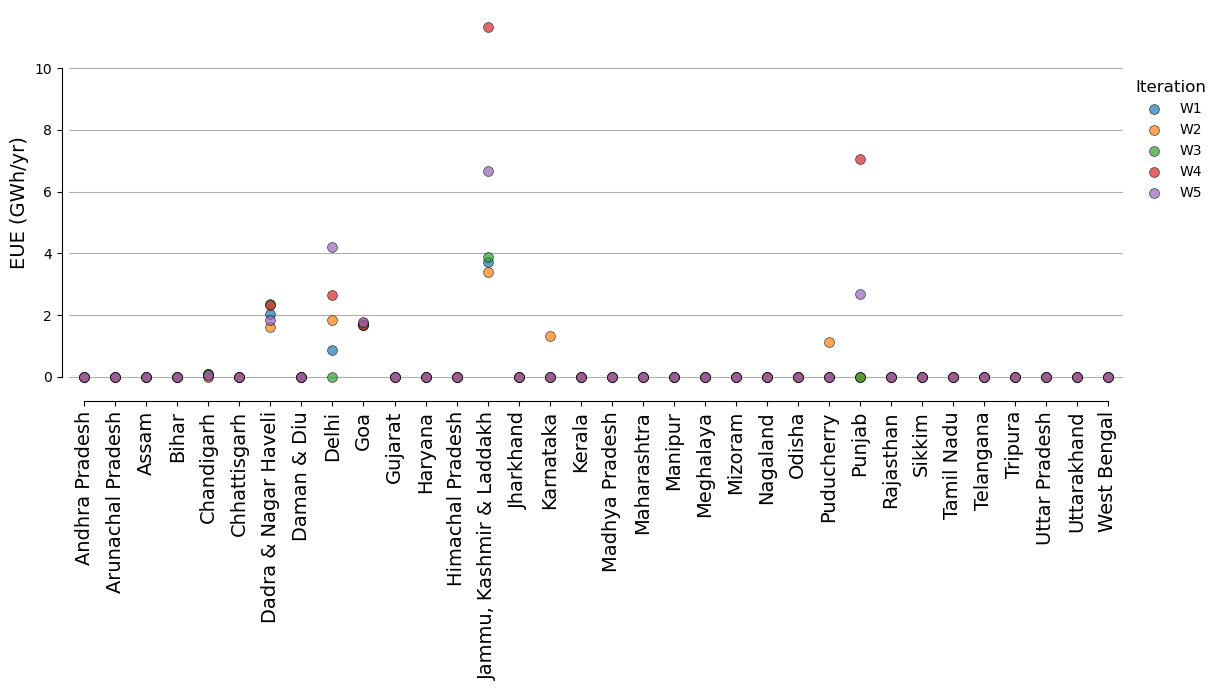

In [6]:
def plot_metrics(ax, df, metric, group_cols = ('W')): 
    
    # 1) remove Bhutan entirely
    df = df[df['load_zone'] != 'Bhutan'].copy()

    # 2) define mapping for special zones
    display_map = {'Jammu_Kashmir': 'Jammu, Kashmir & Laddakh',
                   'Dadra_Nagar_Haveli': 'Dadra & Nagar Haveli',
                   'Daman_Diu': 'Daman & Diu'}

    # 3) determine unique zones (in order of appearance)
    zones = df['load_zone'].unique()
    zone_pos = {zone: idx for idx, zone in enumerate(zones)}

    # 4) build list of display labels in the same order
    zone_labels = [display_map.get(z, z.replace('_', ' ')) for z in zones]

    grouped_data_iterable = df.groupby(list(group_cols))
    
    # Define a key for sorting the groups to ensure W1, W2, ..., W10 sequence
    def sort_key_for_groups(group_item):
        group_key = group_item[0]  # This is 'vals' from groupby
        
        if not group_cols: # Should not happen if group_cols has a default
            return group_key

        # Handle single grouping column (vals is scalar)
        if not isinstance(group_key, tuple):
            if group_cols[0] == 'W':  # Sort numerically if 'W'
                try:
                    return int(group_key)
                except ValueError:
                    return group_key  # Fallback to string sort
            return group_key
        # Handle multiple grouping columns (vals is a tuple)
        else:
            if group_cols[0] == 'W': # Sort by 'W' numerically first
                try:
                    # Create a sort key: (int(W_val), other_vals...)
                    return (int(group_key[0]),) + group_key[1:]
                except (ValueError, TypeError):
                    return group_key  # Fallback
            return group_key # Default tuple sort

    sorted_groups = []
    if group_cols:
        try:
            sorted_groups = sorted(list(grouped_data_iterable), key=sort_key_for_groups)
        except Exception: # Fallback in case of unexpected error during sorting
            sorted_groups = list(grouped_data_iterable)
    else:
        sorted_groups = list(grouped_data_iterable)


    for vals, grp in sorted_groups:  # Iterate over sorted groups
        # Corrected label generation
        current_label = ""
        if isinstance(vals, tuple):  # Multiple grouping columns
            label_parts = []
            for i, col_name in enumerate(group_cols):
                label_parts.append(f"{col_name}{vals[i]}")
            current_label = "-".join(label_parts)
        else:  # Single grouping column
            current_label = f"{group_cols[0]}{vals}"
        
        x = grp['load_zone'].map(zone_pos)
        y = grp[metric]
        
        ax.scatter(x, y, 
                   label      = current_label, 
                   s          = 50, 
                   alpha      = 0.7, 
                   edgecolors = 'black', 
                   lw         = .5, 
                   zorder     = 10)

    # set the custom ticks & labels
    ax.set_xticks(list(zone_pos.values()))

    ax.set_ylabel(metric, fontsize = 14)

    # Add a legend
    ax.legend(
        title='Iteration',
        bbox_to_anchor=(1., .85), # Position legend outside
        loc='upper left',
        fontsize=10,
        title_fontsize=12, frameon=False,
    )
    
    # Add Y-axis gridlines only
    #ax.grid(True, axis='y', linestyle='--', alpha=1.0, linewidth=1.0, zorder=1)
    ax.grid(axis = 'y')

    sns.despine(offset=5, trim=True)
    ax.set_xlim(-.5, len(list(zone_pos.values())) - .5)

    ax.set_xticklabels(zone_labels, 
                       rotation=90, 
                       ha='center', 
                       fontsize=14) 
      

# fig, ax = plt.subplots(figsize = (14, 7))
# plot_metrics(ax, metrics_per_zone_df, metric = 'LOLH (hrs/yr)')
# # Ensure tight_layout is called after all elements are added for proper spacing
# plt.tight_layout(rect=[0, 0, 0.88, 1]) # Adjusted rect slightly for legend
# plt.show()

fig, ax = plt.subplots(figsize = (14, 7))
plot_metrics(ax, metrics_per_zone_df, metric = 'EUE (GWh/yr)')
# Ensure tight_layout is called after all elements are added for proper spacing
plt.tight_layout(rect = [0, 0, 0.88, 1]) # Adjusted rect slightly for legend
plt.show()

# fig, ax = plt.subplots(figsize = (14, 7))
# plot_metrics(ax, metrics_per_zone_df, metric = 'NENS (%)')
# # Ensure tight_layout is called after all elements are added for proper spacing
# plt.tight_layout(rect=[0, 0, 0.88, 1]) # Adjusted rect slightly for legend
# plt.show()

# fig, ax = plt.subplots(figsize = (14, 7))
# plot_metrics(ax, lol_events_df, metric = 'num_LOL_events')
# # Ensure tight_layout is called after all elements are added for proper spacing
# plt.tight_layout(rect=[0, 0, 0.88, 1]) # Adjusted rect slightly for legend
# plt.show()


### Alternative version with non-zero sample only

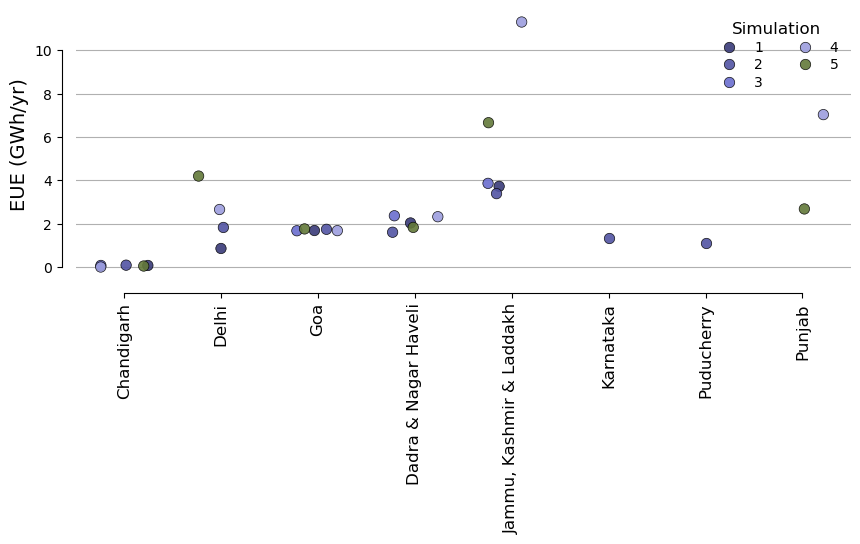

In [7]:
def plot_metrics(ax, df, metric, group_cols = ('W')): 
    
    # 1) remove Bhutan entirely
    df = df[df['load_zone'] != 'Bhutan'].copy()
    df = df.loc[df[metric] > 0.] 

    # 2) define mapping for special zones
    display_map = {'Jammu_Kashmir': 'Jammu, Kashmir & Laddakh',
                   'Dadra_Nagar_Haveli': 'Dadra & Nagar Haveli',
                   'Daman_Diu': 'Daman & Diu'}

    # 3) determine unique zones (in order of appearance)
    zones    = df['load_zone'].unique()
    zone_pos = {zone: idx for idx, zone in enumerate(zones)}

    
    # 4) build list of display labels in the same order
    zone_labels = [display_map.get(z, z.replace('_', ' ')) for z in zones]

    x_ = np.arange(zones.shape[0])

    # for x, zone in zip(x_, zones):
    #     y = df.loc[df['load_zone'] == zone, metric].to_numpy()
    #     print(y.shape)


    ax.set_xticks(x_, list(zone_pos.values()))

    sns.stripplot(data      = df,
                  x         = "load_zone",
                  y         = metric, 
                  size      = "s", 
                  hue       = "iteration",
                  s         = 7.5,
                  alpha     = 0.9, 
                  edgecolor = 'k',
                  linewidth        = .5,
                  zorder    = 9, 
                  jitter    = .25,
                  palette   = "tab20b")

    # set the custom ticks & labels

    ax.set_ylabel(metric, fontsize = 14)
    ax.set_xlabel('', fontsize = 14)

    # Add a legend
    ax.legend(
        title = 'Simulation',
        bbox_to_anchor = (1., 1), # Position legend outside
        #loc='upper right',
        fontsize=10, 
        labelspacing = .25,
        title_fontsize=12, 
        frameon=False, ncol = 2)
    
    # Add Y-axis gridlines only
    #ax.grid(True, axis='y', linestyle='--', alpha=1.0, linewidth=1.0, zorder=1)
    ax.grid(axis = 'y')

    sns.despine(offset=10, trim=True)
    ax.set_xlim(-.5, len(list(zone_pos.values())) - .5)
    
    ax.set_xticklabels(zone_labels, 
                       rotation=90, 
                       ha='center', 
                       fontsize=12) 

df = metrics_per_zone_df.copy()
df['iteration'] = df['W']
df['iteration'] = df['iteration'].astype(int)
df              = df.sort_values(by='iteration')
df['iteration'] = df['iteration'].astype(str)

fig, ax = plt.subplots(figsize = (10., 3.5))
plot_metrics(ax, df, metric = 'EUE (GWh/yr)')
# Ensure tight_layout is called after all elements are added for proper spacing
#plt.tight_layout(rect = [0, 0, 0.88, 1]) # Adjusted rect slightly for legend

plt.savefig(path_to_save_images + '/zone-level_EUE.png',
            bbox_inches = 'tight',
            dpi         = 600)

plt.savefig(path_to_save_images + '/zone-level_EUE.pdf',
            bbox_inches = 'tight',
            dpi         = 600)

plt.show()



# Loss-of-load probability heatmap

In [8]:
df = df_load_.copy()

tau = 1.
df['lol'] = df['unserved_energy'] > tau

df = df[['timepoint', 'load_zone', 'lol']]

df = df.groupby(['timepoint', 'load_zone']).agg({'lol': 'sum'}).reset_index(drop = False)
df = df.groupby(['timepoint']).agg({'lol': 'sum'}).reset_index(drop = False)

df['interval'] = df['timepoint'].apply(lambda x: int(str(x)[-2:]))
df['month']    = df['timepoint'].apply(lambda x: int(str(x)[-6:-4]))

df = df[['month', 'interval', 'lol']]
df = df.groupby(['month', 'interval']).agg({'lol': 'sum'}).reset_index(drop = False)
print(df)

months_    = np.array([4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3])
intervals_ = df['interval'].unique()
LOLP_      = np.zeros((months_.shape[0], intervals_.shape[0]))

for m, month in zip(range(months_.shape[0]), months_):
    for interval in intervals_:
        print(df.loc[(df['month'] == month) & (df['interval'] == interval), 'lol'].to_numpy()[0], calendar.monthrange(2001, month)[1])
        LOLP_[m, interval - 1] = df.loc[(df['month'] == month) & (df['interval'] == interval), 'lol'].to_numpy()[0]/(18*calendar.monthrange(2001, month)[1])

print(LOLP_.max(), LOLP_.min())

     month  interval  lol
0        1         1    0
1        1         2    0
2        1         3    0
3        1         4    0
4        1         5    0
..     ...       ...  ...
283     12        20    0
284     12        21    0
285     12        22    0
286     12        23    0
287     12        24    0

[288 rows x 3 columns]
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30

0.0 0.0 0.08781362007168458


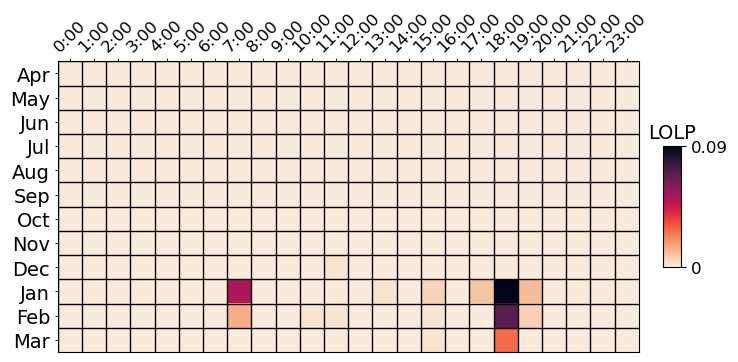

In [9]:
print(LOLP_[0, 18], LOLP_.min(), LOLP_.max())

fig, ax = plt.subplots(figsize = (7.5, 7.5))

month_    = ['Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar']
interval_ = [ f'{interval}:00' for interval in np.arange(24, dtype = int)]

_cmap = sns.color_palette("rocket_r", as_cmap = True)

LOLP_p = LOLP_.copy()
LOLP_p[LOLP_ == 0.] = np.nan
ax.matshow(LOLP_, 
           cmap   = _cmap, 
           vmin   = 0., 
           extent = [0, 24, 12, 0])

ax.set_yticks(range(len(month_)), []*len(month_))
ax.set_xticks(range(len(interval_)), []*len(interval_))

ax.set_yticks(np.arange(len(month_), dtype = int) + 0.5, month_, 
              rotation = 0, 
              minor    = True, 
              size     = 14)

ax.set_xticks(np.arange(len(interval_), dtype = int) + 0.5, interval_,
              rotation = 45,
              minor    = True, 
              size     = 12)

ax.tick_params(which  = 'major', 
               bottom = False, 
               left   = False, 
               top    = False)

ax.tick_params(which  = 'minor', 
               bottom = False, 
               top    = True)

ax.grid(which     = 'major', 
        color     = 'k', 
        linestyle = '-', 
        linewidth = 1.)

cbar = fig.colorbar(cm.ScalarMappable(cmap = _cmap), 
                    cax = ax.inset_axes([25, 3.5, .75, 5], transform = ax.transData), 
                    orientation = 'vertical')

cbar.set_ticks([0, 1], labels = ['0', f'{np.round(LOLP_.max(), 2)}'], size = 12)
#cbar.ax.tick_params(length = 0)
cbar.ax.set_title('LOLP', rotation = 0, size = 14)

plt.savefig(path_to_save_images + '/zone-level_LOLP_heatmap.png',
            bbox_inches = 'tight',
            dpi         = 600)

plt.savefig(path_to_save_images + '/zone-level_LOLP_heatmap.pdf',
            bbox_inches = 'tight',
            dpi         = 600)

plt.show()

# Loss-of-load events distribution

In [10]:
df = df_load_.copy()

# This is at the national-level!
df = df.groupby(['timestamp', 'W', 'H', 'A', 'load_zone']).agg({'unserved_energy': 'sum'}).reset_index(drop = False)

df['iteration'] = df['W'] + df['H'] + df['A']
df = df[['iteration', 'timestamp', 'load_zone', 'unserved_energy']]

df = df.sort_values(by = ['iteration', 'timestamp', 'load_zone']).reset_index(drop = True)

# Load shedding greater than 1MW
tau = 1.

df_events_ = []
for load_zone in df['load_zone'].unique():
    print(load_zone)
    for iter in df['iteration'].unique():
        idx_ = (df['iteration'] == iter) & (df['load_zone'] == load_zone)
        if idx_.sum() > 0:
            run                = df.loc[idx_].copy()
            run['is_lol']      = run['unserved_energy'] > tau
            run['event_start'] = (~run['is_lol'].shift(fill_value=False)) & run['is_lol']
            run['event_id']    = run['event_start'].cumsum()
            #print(load_zone, iter, (run['unserved_energy'] > 0).sum(), run['is_lol'].sum())

            df_event_              = pd.DataFrame(columns = ['hours', 'load_zone', 'iteration'])
            df_event_['hours']     = run[run['is_lol']].groupby('event_id').size().to_numpy()
            df_event_['load_zone'] = load_zone
            df_event_['iteration'] = iter

            df_events_.append(df_event_)

df_events_ = pd.concat(df_events_, axis = 0).reset_index(drop = True)
print(df_events_.head())

Andhra_Pradesh
Arunachal_Pradesh
Assam
Bhutan
Bihar
Chandigarh
Chhattisgarh
Dadra_Nagar_Haveli
Daman_Diu
Delhi
Goa
Gujarat
Haryana
Himachal_Pradesh
Jammu_Kashmir
Jharkhand
Karnataka
Kerala
Madhya_Pradesh
Maharashtra
Manipur
Meghalaya
Mizoram
Nagaland
Odisha
Puducherry
Punjab
Rajasthan
Sikkim
Tamil_Nadu
Telangana
Tripura
Uttar_Pradesh
Uttarakhand
West_Bengal
   hours   load_zone iteration
0      1  Chandigarh       111
1      1  Chandigarh       222
2      1  Chandigarh       333
3      1  Chandigarh       444
4      1  Chandigarh       444


[1 2 3] 156
[136.   7.   2.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15.]
(14,) (15,)


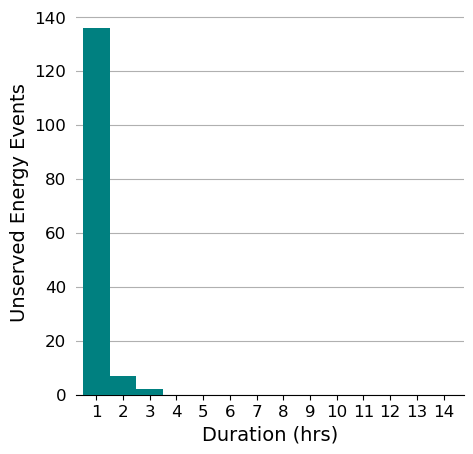

In [11]:
def _plot_LOLE_distribution(ax, df_events_):
    print(df_events_['hours'].unique(), df_events_['hours'].sum())

    (n, bins, patches) = ax.hist(df_events_['hours'], bins = 14, range = (1, 15), zorder = 5, color = 'teal')
    print(n)
    print(bins)
    print(n.shape, bins.shape)

    ax.set_xlabel('Duration (hrs)', fontsize = 14)
    ax.set_ylabel('Unserved Energy Events', fontsize = 14)
    ax.set_xticks(np.arange(0, 15, 1) + 1.5)
    ax.set_xticklabels(bins.astype(int))

    ax.set_xlim(bins.min() - .25, bins.max() + .25)
    ax.set_ylim(0, )

    ax.xaxis.set_tick_params(labelsize = 12)
    ax.yaxis.set_tick_params(labelsize = 12, left = False)

    ax.spines[['right', 'top', 'left']].set_visible(False)
    ax.grid(axis = 'y', zorder = 0)

fig, ax = plt.subplots(figsize = (5, 5))

_plot_LOLE_distribution(ax, df_events_)

plt.savefig(path_to_save_images + '/zone-level_LOLE_distribution.png',
            bbox_inches = 'tight',
            dpi         = 600)

plt.savefig(path_to_save_images + '/zone-level_LOLE_distribution.pdf',
            bbox_inches = 'tight',
            dpi         = 600)

plt.show()

# Unserved energy distribution

In [12]:
df_duration = df_load_.copy()
df_duration = df_duration[['timepoint','W','H','A','load_zone','unserved_energy','net_imports']]

df_unserved_energy = df_duration.copy()
df_unserved_energy= df_unserved_energy[['timepoint','W','H','A','load_zone','unserved_energy']]
# drop all the rows with unserved energy = 0
df_unserved_energy = df_unserved_energy[df_unserved_energy['unserved_energy'] > 0]
#sum unserved energy by timepoint for each load zone
df_unserved_energy = df_unserved_energy.groupby(['timepoint','W','H','A','load_zone']).agg({'unserved_energy': 'sum'}).reset_index(drop = False)
# drop W,H,A columns
df_unserved_energy = df_unserved_energy.drop(columns=['W','H','A'])
#sum unserved energy for all load zones timepoint wise
df_unserved_energy = df_unserved_energy.groupby(['timepoint']).agg({'unserved_energy': 'sum'}).reset_index(drop = False)
# arrane unserved energy in descending order
df_unserved_energy = df_unserved_energy.sort_values(by=['unserved_energy'], ascending=False).reset_index(drop = True)
print(df_unserved_energy.shape)

(92, 2)


In [13]:
df = df_load_.copy()

# This is at the national-level!
df = df.groupby(['timestamp', 'load_zone', 'W', 'H', 'A']).agg({'unserved_energy': 'sum'}).reset_index(drop = False)

df['W'] = df['W'].astype(int)
df['H'] = df['H'].astype(int)
df['A'] = df['A'].astype(int)

df = df.sort_values(by = ['W', 'H', 'A', 'timestamp', 'load_zone'])

# Load shedding greater than 1MW
tau = 1

df = df.loc[df['unserved_energy'] > tau].reset_index(drop = True)
print(df.shape)


(156, 6)


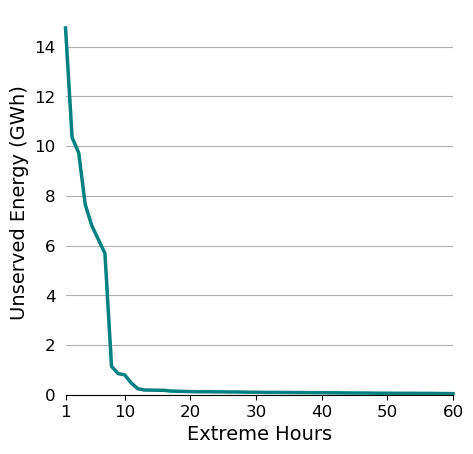

In [14]:
def _plot_unsrved_energy_dist(ax, df, cutoff = 50):
    x_ = range(1, len(df) + 1)
    y_ = df['unserved_energy']/1e3
    ax.plot(x_[:cutoff], y_[:cutoff], lw = 2.5, clip_on = False, color = 'teal')
    ax.set_xlabel('Extreme Hours', fontsize = 14)
    ax.set_ylabel('Unserved Energy (GWh)', fontsize = 14)
    # ax.title('Distribution of Unserved Energy')
    ax.set_xlim(1, cutoff)
    ax.set_ylim(0, )
    ax.xaxis.set_tick_params(labelsize = 12)
    ax.yaxis.set_tick_params(labelsize = 12, left = False)
    ax.spines[['right', 'top', 'left']].set_visible(False)
    ax.set_xticks([1, 10, 20, 30, 40, 50, 60], [1, 10, 20, 30, 40, 50, 60])
    ax.grid(axis = 'y')

fig, ax = plt.subplots(figsize = (5, 5))

_plot_unsrved_energy_dist(ax, df_unserved_energy, cutoff = 60)

plt.savefig(path_to_save_images + '/zone-level_unserved_energy_distribution.png',
            bbox_inches = 'tight',
            dpi         = 600)
plt.savefig(path_to_save_images + '/zone-level_unserved_energy_distribution.pdf',
            bbox_inches = 'tight',
            dpi         = 600)

plt.show()

# Net imports distribution

(455,)


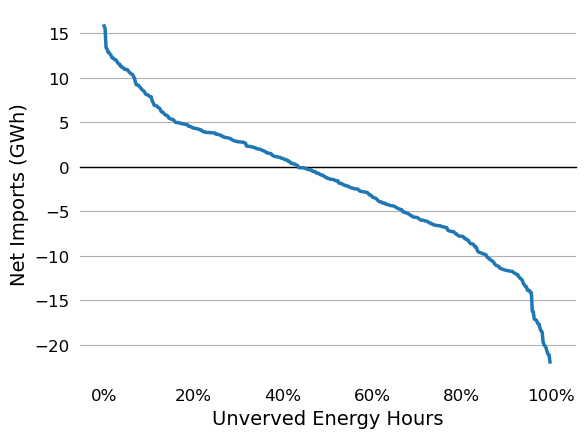

In [15]:
df = df_load_.copy()

# assume df_duration already has ['timepoint','load_zone','net_imports', …]
zone = 'Tamil_Nadu'  # ← replace with the zone you want

# Load shedding greater than 1MW
tau = 1

# This is at the national-level!
df = df.groupby(['timestamp', 'load_zone', 'W', 'H', 'A']).agg({'unserved_energy': 'sum', 'net_imports': 'sum'}).reset_index(drop = False)

df['W'] = df['W'].astype(int)
df['H'] = df['H'].astype(int)
df['A'] = df['A'].astype(int)

df = df.sort_values(by = ['W', 'H', 'A', 'timestamp', 'load_zone'])
df = df.loc[df['timestamp'].isin(df.loc[df['unserved_energy'] > tau, 'timestamp'].unique())].reset_index(drop = True)
df = df[df['load_zone'] == zone]

def plot_net_import_dist(ax, df):
    x_ = range(1, len(df) + 1)
    y_ = df['net_imports'].to_numpy()/1e3
    print(y_.shape)
    ax.plot(np.arange(y_.shape[0], dtype = int), np.sort(y_)[::-1], lw = 2.5, clip_on = True, zorder = 5)
    ax.set_xlabel('Unverved Energy Hours', fontsize = 14)
    ax.set_ylabel('Net Imports (GWh)', fontsize = 14)
    # ax.title('Distribution of Unserved Energy')
    ax.set_xlim(-25, y_.shape[0] + 25)
    ax.xaxis.set_tick_params(labelsize = 12, bottom = False)
    ax.yaxis.set_tick_params(labelsize = 12, left = False)
    ax.spines[['right', 'top', 'left','bottom']].set_visible(False)
    ax.set_xticks(np.linspace(0, y_.shape[0], 6), [f'{i*20}%' for i in np.arange(6, dtype = int)])
    ax.axhline(0, linewidth = 1.,
                  linestyle = '-',
                  color     = 'k',
                  clip_on   = False, 
                  zorder    = 4)
    
    ax.grid(axis   = 'y', 
            zorder = 1)

fig = plt.figure()
ax  = fig.add_subplot(111)

plot_net_import_dist(ax, df)

In [16]:
# assume df_duration already has ['timepoint','load_zone','net_imports', …]
zone = 'Karnataka'  # ← replace with the zone you want

# 1. filter out zeros and unwanted columns
df_zone = (df_duration.loc[df_duration['net_imports'] != 0, ['timepoint','load_zone','net_imports']])

# 2. keep only your zone
df_zone = df_zone[df_zone['load_zone'] == zone]

# 3. group by timepoint and sum
df_zone_import = (df_zone.groupby('timepoint', as_index=False)['net_imports'].sum())

# 4. sort if you like
df_zone_import = df_zone_import.sort_values('net_imports', ascending=False)

print(df_zone_import.head())

       timepoint   net_imports
8182  2041030723  92623.767338
7681  2041021502  92132.057037
6691  2041010420  92018.805631
7584  2041021101  91907.029300
8540  2041032221  91540.603410


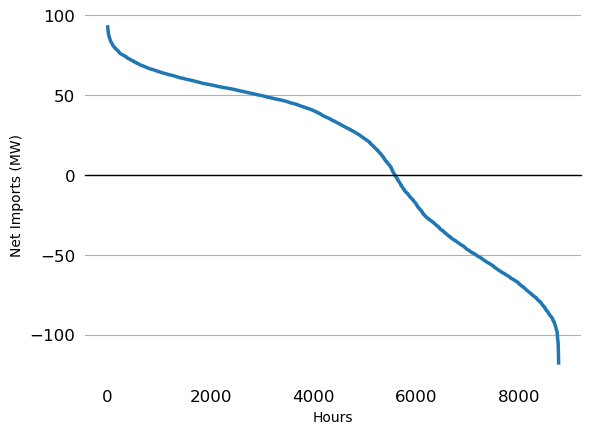

In [17]:
def plot_net_import_dist(ax, df):
    x_ = range(1, len(df) + 1)
    y_ = df['net_imports']/1e3

    ax.plot(x_, y_, lw = 2.5)
    ax.set_xlabel('Hours')
    ax.set_ylabel('Net Imports (MW)')
    # ax.title('Distribution of Unserved Energy')
    # ax.set_xlim(0.9,50)
    # ax.set_ylim(0, )
    ax.xaxis.set_tick_params(labelsize = 12, bottom = False)
    ax.yaxis.set_tick_params(labelsize = 12, left = False)
    ax.spines[['right', 'top', 'left','bottom']].set_visible(False)
    # ax.set_xticks([1, 10, 20, 30, 40, 50], [1, 10, 20, 30, 40, 50])
    ax.grid(axis = 'y')
    ax.axhline(0, linewidth = 1.,
                  linestyle = '-',
                  color     = 'k',
                  clip_on   = False)

fig = plt.figure()
ax = fig.add_subplot(111)

plot_net_import_dist(ax, df_zone_import)

# Load and processing project timepoints

In [18]:
# Load and processing project timepoints
def _processing_project_timepoints(scenarios_):

    dfs_ = []
    for scenario, path_to_scenarios in zip(scenarios_['scenario'], scenarios_['path']):
        path_to_scenario = os.path.join(path_to_scenarios, scenario)

        for dirpath, dirnames, filenames in os.walk(path_to_scenario):
            # Processing scenarios results folder only
            if dirpath.split('/')[-1] == 'results':
                print(scenario)

                df_ = pd.read_csv(os.path.join(dirpath, 'project_timepoint.csv'), low_memory = False)

                df_ = df_[['timepoint', 
                           'technology', 
                           'load_zone', 
                           'power_mw',
                           'capacity_mw',
                           'starting_energy_mwh', 
                           'charge_mw', 
                           'discharge_mw', 
                           'total_curtailment_mw']] # availability_derate
               
                df_ = df_.groupby(['timepoint',
                                   'technology', 
                                   'load_zone']).agg({'power_mw': 'sum',
                                                      'total_curtailment_mw': 'sum',
                                                      'starting_energy_mwh': 'sum',
                                                      'charge_mw': 'sum',
                                                      'discharge_mw': 'sum',
                                                      'capacity_mw' : 'sum'}).reset_index(drop = False)
                
                df_ = df_.rename(columns = {'total_curtailment_mw': 'curtailment_mw',
                                            'starting_energy_mwh': 'energy_mwh'})
                
                # Add iteration descriptors to dataframe
                df_['W'] = dirpath.split('/')[-4].split('_')[-1]
                df_['H'] = dirpath.split('/')[-3].split('_')[-1]
                df_['A'] = dirpath.split('/')[-2].split('_')[-1]
                
                dfs_.append(df_)

    return pd.concat(dfs_).reset_index(drop = True)

# Group project timepoints by technology
def _group_technology_in_project_timepoints(df_, tech_labels_):

    for group in tech_labels_['group'].unique():
        df_.loc[df_['technology'].isin(tech_labels_.loc[tech_labels_['group'] == group, 'technology']), 'technology'] = group
        
    return df_.groupby(['timepoint',
                        'technology', 
                        'load_zone',
                        'W','H','A']).agg({'power_mw': 'sum',
                                           'capacity_mw' : 'sum',
                                           'curtailment_mw': 'sum',
                                           'energy_mwh': 'sum',
                                           'charge_mw': 'sum',
                                           'discharge_mw': 'sum'}).reset_index(drop = False)

# Load, process and group project timepoints
df_dispatch_ = _processing_project_timepoints(scenarios_)
df_dispatch_ = _group_technology_in_project_timepoints(df_dispatch_, tech_labels_)
print(df_dispatch_.head())

pier_prm_100_no_ccap_2040_1
pier_prm_100_no_ccap_2040_2
pier_prm_100_no_ccap_2040_3
pier_prm_100_no_ccap_2040_4
pier_prm_100_no_ccap_2040_5
    timepoint technology       load_zone  W  H  A  power_mw  capacity_mw  \
0  2040040101    Battery  Andhra_Pradesh  1  1  1       0.0  1307.539941   
1  2040040101    Battery  Andhra_Pradesh  2  2  2       0.0  1307.539941   
2  2040040101    Battery  Andhra_Pradesh  3  3  3       0.0  1307.539941   
3  2040040101    Battery  Andhra_Pradesh  4  4  4       0.0  1307.539941   
4  2040040101    Battery  Andhra_Pradesh  5  5  5       0.0  1307.539941   

   curtailment_mw   energy_mwh  charge_mw  discharge_mw  
0             0.0     0.000000        0.0           0.0  
1             0.0  2588.929083        0.0           0.0  
2             0.0     0.000000        0.0           0.0  
3             0.0  1407.026676        0.0           0.0  
4             0.0     0.000000        0.0           0.0  


In [19]:
# add tiemstamp to df_dispatch_
# Create a timestamp column from 'timepoint' field (YYYYMMDDHH)
tp = df_dispatch_['timepoint'].astype(str)
dates = tp.str[:8]
hours = tp.str[8:].astype(int)  #1-24

df_dispatch_['timestamp'] = (
    pd.to_datetime(dates, format='%Y%m%d')
    + pd.to_timedelta(hours, unit='h')
)
# Reorder so timestamp is first
cols = df_dispatch_.columns.tolist()
cols.insert(0, cols.pop(cols.index('timestamp')))
df_dispatch_ = df_dispatch_[cols]

#Calculation of Renewable Energy Drought

In [20]:
# Filter for Wind and Solar technologies
df_wind = df_dispatch_[df_dispatch_['technology'] == 'Wind']
df_solar = df_dispatch_[df_dispatch_['technology'] == 'Solar']

# Group and sum Wind power and capacity by load_zone and timestamp
wind_grouped = df_wind.groupby(['load_zone', 'timestamp','W','H','A'], as_index=False)[['power_mw', 'capacity_mw']].sum()

# Group and sum Solar power and capacity by load_zone and timestamp
solar_grouped = df_solar.groupby(['load_zone', 'timestamp','W','H','A'], as_index=False)[['power_mw', 'capacity_mw']].sum()

# Merge the grouped Wind and Solar DataFrames
merged_df = pd.merge(
    wind_grouped, 
    solar_grouped, 
    on=['load_zone', 'timestamp','W','H','A'], 
    how='outer', 
    suffixes=('_wind', '_solar')
)

# Sum the Wind and Solar power and capacity into new columns
merged_df['total_renewable_mwh'] = merged_df['power_mw_wind'] + merged_df['power_mw_solar']
merged_df['total_renewable_capacity_mw'] = merged_df['capacity_mw_wind'] + merged_df['capacity_mw_solar']

# Select the final columns - no need for additional grouping
renewable_dispatch = merged_df[['load_zone', 'timestamp', 'W','H','A','total_renewable_mwh', 'total_renewable_capacity_mw']]

# net_cf=renewable_dispatch.copy()
# net_cf['capacity_factor'] = net_cf['total_renewable_mwh'] / net_cf['total_renewable_capacity_mw']

# # filter only the solar hours i.e. 9 AM to 5 PM
# net_cf = net_cf[(net_cf['timestamp'].dt.hour >= 9) & (net_cf['timestamp'].dt.hour < 17)]

# # keep the values whose capacity factor is below 0.025
# net_cf = net_cf[net_cf['capacity_factor'] < 0.025]


# calculation by average Plant load factor method

In [21]:

plf_df = renewable_dispatch.copy()

window_days = 2  

# Convert timestamp to plain date (YYYY-MM-DD)
plf_df['date'] = plf_df['timestamp'].dt.date  

# Aggregate to daily total generation and capacity
daily_df = (
    plf_df.groupby(['load_zone','W','H','A','date'], as_index=False)
          [['total_renewable_mwh','total_renewable_capacity_mw']].sum()
)

# Daily PLF
daily_df['daily_plf'] = (
    daily_df['total_renewable_mwh'] / daily_df['total_renewable_capacity_mw']
)

# Rolling PLF over 2 days
daily_df['plf'] = (
    daily_df.groupby(['load_zone','W','H','A'])['daily_plf']
            .transform(lambda x: x.rolling(window=window_days, min_periods=1).mean())
)

# Final dataframe (date-only, no hh:mm)
plf_df = daily_df.drop(columns=['daily_plf'])


In [22]:
# df_dispatch_ must have: timepoint, technology, load_zone, power_mw, capacity_mw, W, H, A

# 1) Correct timestamp (timepoints encoded as YYYYMMDDHH with HH=1..24)
tp = df_dispatch_['timepoint'].astype(str)
dates = pd.to_datetime(tp.str[:8], format='%Y%m%d')
hours = tp.str[8:].astype(int)  # 1..24
df_dispatch_ = df_dispatch_.copy()
df_dispatch_['timestamp'] = dates + pd.to_timedelta(hours - 1, unit='h')  # <-- fix at source

# 2) Wind & Solar hourly (sum if multiples)
keys = ['load_zone','timestamp','W','H','A']
cols = keys + ['power_mw','capacity_mw','technology']
ws = df_dispatch_.loc[df_dispatch_['technology'].isin(['Wind','Solar']), cols].copy()

wind = (ws[ws['technology']=='Wind']
        .groupby(keys, as_index=False)[['power_mw','capacity_mw']].sum()
        .rename(columns={'power_mw':'power_mw_wind','capacity_mw':'capacity_mw_wind'}))

solar = (ws[ws['technology']=='Solar']
         .groupby(keys, as_index=False)[['power_mw','capacity_mw']].sum()
         .rename(columns={'power_mw':'power_mw_solar','capacity_mw':'capacity_mw_solar'}))

# 3) Merge wind+solar, fill zeros BEFORE summing
merged = (pd.merge(wind, solar, on=keys, how='outer')
            .fillna({'power_mw_wind':0.0, 'capacity_mw_wind':0.0,
                     'power_mw_solar':0.0, 'capacity_mw_solar':0.0}))

merged['total_power_mw']    = merged['power_mw_wind']    + merged['power_mw_solar']
merged['total_capacity_mw'] = merged['capacity_mw_wind'] + merged['capacity_mw_solar']

# 4) Day assignment (NO extra 1h shift now that timestamp is fixed)
merged['date'] = merged['timestamp'].dt.normalize()

# 5) Daily PLF and 48h (2-day) rolling PLF
daily = (merged.groupby(['load_zone','W','H','A','date'], as_index=False)
         .agg(energy_mwh_day=('total_power_mw','sum'),
              cap_hour_sum_day=('total_capacity_mw','sum')))

daily['plf_day'] = np.where(
    daily['cap_hour_sum_day'] > 0,
    daily['energy_mwh_day'] / daily['cap_hour_sum_day'],
    np.nan
)

window_days = 2  # 48 hours
daily = daily.sort_values(['load_zone','W','H','A','date'])
daily['plf'] = (daily.groupby(['load_zone','W','H','A'])['plf_day']
                .transform(lambda s: s.rolling(window=window_days, min_periods=1).mean()))

# 6) Final day-wise PLF dataframe + flag
plf_df = daily[['load_zone','W','H','A','date','plf']].copy()
plf_threshold = 0.025
plf_df['low_plf_flag'] = np.where(plf_df['plf'].notna() & (plf_df['plf'] < plf_threshold), 1, 0).astype('int8')

# 7) Enforce fiscal year window: Apr 1 → Mar 31 (change fy as needed)
fy = 2040  # FY 2040–41
fy_start = pd.Timestamp(f"{fy}-04-01")
fy_end   = pd.Timestamp(f"{fy+1}-03-31")

plf_df = plf_df[(plf_df['date'] >= fy_start) & (plf_df['date'] <= fy_end)].copy()
plf_df = plf_df.sort_values(['load_zone','W','H','A','date']).reset_index(drop=True)


#Calculation of top net demand days 

In [23]:
TOP_K = 5
FY = None           # e.g., 2040 for FY 2040–41 (Apr 1 → Mar 31), or None to skip

# Helper: correct timestamp from timepoint with hours 1..24
def _timestamp_from_timepoint(df, tp_col='timepoint'):
    tp = df[tp_col].astype(str)
    d  = pd.to_datetime(tp.str[:8], format='%Y%m%d')
    h  = tp.str[8:].astype(int)  # 1..24
    return d + pd.to_timedelta(h - 1, unit='h')

# 1) Ensure aligned timestamps on load & dispatch
df_load_ = df_load_.copy()
if 'timestamp' not in df_load_.columns:
    df_load_['timestamp'] = _timestamp_from_timepoint(df_load_)
df_load_['date'] = df_load_['timestamp'].dt.normalize()

df_dispatch_ = df_dispatch_.copy()
if 'timestamp' not in df_dispatch_.columns:
    df_dispatch_['timestamp'] = _timestamp_from_timepoint(df_dispatch_)

# 2) Build hourly RE total (Wind + Solar) per zone/W/H/A/timestamp
keys = ['load_zone','timestamp','W','H','A']
ws = df_dispatch_.loc[df_dispatch_['technology'].isin(['Wind','Solar']),
                      keys + ['power_mw','capacity_mw','technology']].copy()

wind = (ws[ws['technology']=='Wind']
        .groupby(keys, as_index=False)[['power_mw','capacity_mw']].sum()
        .rename(columns={'power_mw':'power_mw_wind','capacity_mw':'capacity_mw_wind'}))

solar = (ws[ws['technology']=='Solar']
         .groupby(keys, as_index=False)[['power_mw','capacity_mw']].sum()
         .rename(columns={'power_mw':'power_mw_solar','capacity_mw':'capacity_mw_solar'}))

re_merged = (pd.merge(wind, solar, on=keys, how='outer')
               .fillna({'power_mw_wind':0.0, 'capacity_mw_wind':0.0,
                        'power_mw_solar':0.0, 'capacity_mw_solar':0.0}))
re_merged['total_re_mw'] = re_merged['power_mw_wind'] + re_merged['power_mw_solar']

# 3) Build netload_df = static_load − total_re_mw (hourly, PER ZONE)
netload_df = pd.merge(
    df_load_[keys + ['static_load']],
    re_merged[keys + ['total_re_mw']],
    on=keys, how='left'
).fillna({'total_re_mw': 0.0})

netload_df['net_load_mw'] = netload_df['static_load'] - netload_df['total_re_mw']
netload_df['date'] = netload_df['timestamp'].dt.normalize()

# (optional) restrict to fiscal year Apr 1 → Mar 31
if FY is not None:
    fy_start = pd.Timestamp(f"{FY}-04-01")
    fy_end   = pd.Timestamp(f"{FY+1}-03-31")
    netload_df = netload_df[(netload_df['date'] >= fy_start) & (netload_df['date'] <= fy_end)].copy()

# 4) Per-zone hourly net load (sum only in case of duplicates)
zone_hourly = (netload_df.groupby(['load_zone','W','H','A','timestamp'], as_index=False)['net_load_mw'].sum())
zone_hourly['date'] = zone_hourly['timestamp'].dt.normalize()

# 5) Per-zone DAILY PEAK net load (MW)
daily_peak_zone = (
    zone_hourly.groupby(['load_zone','W','H','A','date'], as_index=False)['net_load_mw']
               .max()
               .rename(columns={'net_load_mw':'daily_peak_net_load_mw'})
)

# 6) Top 5 days per (load_zone, W, H, A)
top5_zone_netload_days = (
    daily_peak_zone.sort_values(['load_zone','W','H','A','daily_peak_net_load_mw'],
                                ascending=[True, True, True, True, False])
                    .groupby(['load_zone','W','H','A'])
                    .head(TOP_K)
                    .reset_index(drop=True)
)

# (nice to have) rank within each zone+iteration
top5_zone_netload_days['rank'] = (
    top5_zone_netload_days.groupby(['load_zone','W','H','A'])['daily_peak_net_load_mw']
                          .rank(ascending=False, method='first').astype(int)
)

# make date a pure date object (no hh:mm:ss)
top5_zone_netload_days['date'] = pd.to_datetime(top5_zone_netload_days['date']).dt.date

# - netload_df: hourly net load by zone/W/H/A
# - top5_zone_netload_days: top 5 daily-peak net-load days for each (load_zone, W, H, A)


In [24]:
# Merging netyload with plf
# Make dates comparable (no hh:mm)
plf_df = plf_df.copy()
plf_df['date'] = pd.to_datetime(plf_df['date']).dt.date
top5_zone_netload_days['date'] = pd.to_datetime(top5_zone_netload_days['date']).dt.date

# Align dtypes on join keys
for c in ['load_zone','W','H','A']:
    plf_df[c] = plf_df[c].astype(str)
    top5_zone_netload_days[c] = top5_zone_netload_days[c].astype(str)

# Keys
keys = ['load_zone','W','H','A','date']

# Build the flag from the top-5 table
top5_keys = top5_zone_netload_days[keys].drop_duplicates().assign(net_load=1)

# Merge into plf_df; fill others as 0
plf_df = (
    plf_df.drop(columns=['net_load'], errors='ignore')
          .merge(top5_keys, on=keys, how='left')
)
plf_df['net_load'] = plf_df['net_load'].fillna(0).astype('int8')

In [25]:
# Adding unserved energy to plf
# --- make dates comparable (no hh:mm) ---
plf_df = plf_df.copy()
plf_df['date'] = pd.to_datetime(plf_df['date']).dt.date

df_ls = df_load_.copy()

# If df_load_ doesn't already have the fixed timestamp (1..24 → hours-1), build it:
if 'timestamp' not in df_ls.columns:
    tp = df_ls['timepoint'].astype(str)
    d  = pd.to_datetime(tp.str[:8], format='%Y%m%d')
    h  = tp.str[8:].astype(int)  # 1..24
    df_ls['timestamp'] = d + pd.to_timedelta(h - 1, unit='h')

df_ls['date'] = df_ls['timestamp'].dt.date

# --- build daily presence flag for load shedding (>0) per zone & W,H,A ---
keys = ['load_zone','W','H','A','date']
ls_presence = (
    df_ls.loc[df_ls['unserved_energy'] > 0, keys]
         .drop_duplicates()
         .assign(load_shedding=1)
)

# align dtypes on join keys (avoid int/str mismatches)
for k in ['load_zone','W','H','A']:
    plf_df[k]      = plf_df[k].astype(str)
    ls_presence[k] = ls_presence[k].astype(str)

# --- merge into plf_df; fill others as 0 ---
plf_df = (
    plf_df.drop(columns=['load_shedding'], errors='ignore')
          .merge(ls_presence, on=keys, how='left')
)
plf_df['load_shedding'] = plf_df['load_shedding'].fillna(0).astype('int8')


# Dataframe with weather indices and impact on LOL

In [26]:

# ---- keys we’ll reuse ----
keys4 = ['load_zone','W','H','A']

# start from plf_df
final_df = plf_df.copy()
final_df['date'] = pd.to_datetime(final_df['date']).dt.normalize()

# =========================
# 1) Expected EUE per (zone, W, H, A) and daily load shedding
# =========================
ls = df_load_.copy()

# ensure a correct hourly timestamp (1..24 encoded hours → hours-1)
if 'timestamp' not in ls.columns:
    tp = ls['timepoint'].astype(str)
    d  = pd.to_datetime(tp.str[:8], format='%Y%m%d')
    h  = tp.str[8:].astype(int)  # 1..24
    ls['timestamp'] = d + pd.to_timedelta(h - 1, unit='h')

ls['date'] = ls['timestamp'].dt.normalize()

# (optional but helps keep “one year” aligned with plf_df’s span)
ls = ls.merge(final_df[keys4].drop_duplicates(), on=keys4, how='inner')
ls = ls[(ls['date'] >= final_df['date'].min()) & (ls['date'] <= final_df['date'].max())]

# daily unserved energy per zone & iteration (assumes hourly steps → sum(MW)=MWh)
ls_daily = (
    ls.groupby(keys4 + ['date'], as_index=False)['unserved_energy']
      .sum()
      .rename(columns={'unserved_energy': 'load_shedding_mwh'})
)

# expected EUE over the year window (per zone & iteration)
expected_eue = (
    ls_daily.groupby(keys4, as_index=False)['load_shedding_mwh']
            .sum()
            .rename(columns={'load_shedding_mwh':'expected_eue_mwh'})
)

# merge into final_df
final_df = final_df.merge(ls_daily, on=keys4 + ['date'], how='left')
final_df['load_shedding_mwh'] = final_df['load_shedding_mwh'].fillna(0)

final_df = final_df.merge(expected_eue, on=keys4, how='left')
final_df['expected_eue_mwh'] = final_df['expected_eue_mwh'].fillna(0)

# ratio: daily load shedding as a share of expected EUE
final_df['load_shedding_eue'] = np.where(
    final_df['expected_eue_mwh'] > 0,
    final_df['load_shedding_mwh'] / final_df['expected_eue_mwh'],
    np.nan
)

# =========================
# 2) Ratio to maximum of top net load
# =========================
nl = netload_df.copy()
nl['timestamp'] = pd.to_datetime(nl['timestamp'])
nl['date'] = nl['timestamp'].dt.normalize()

# daily PEAK net load (MW)
nl_daily_peak = (
    nl.groupby(keys4 + ['date'], as_index=False)['net_load_mw']
      .max()
      .rename(columns={'net_load_mw':'daily_peak_netload_mw'})
)

# max of the top-5 daily peaks per (zone, W, H, A)
top5_max = (
    nl_daily_peak.sort_values(keys4 + ['daily_peak_netload_mw'],
                              ascending=[True, True, True, True, False])
                 .groupby(keys4, as_index=False).head(5)
                 .groupby(keys4, as_index=False)['daily_peak_netload_mw']
                 .max()
                 .rename(columns={'daily_peak_netload_mw':'top_netload_max_mw'})
)

# merge denom and compute ratio
final_df = final_df.merge(top5_max, on=keys4, how='left')
final_df['load_shedding_top_net_load'] = np.where(
    final_df['top_netload_max_mw'] > 0,
    final_df['load_shedding_mwh'] / final_df['top_netload_max_mw'],
    np.nan
)

# date as plain date (no time)
final_df['date'] = final_df['date'].dt.date


# Heatmap of Renewable Energy Drought days

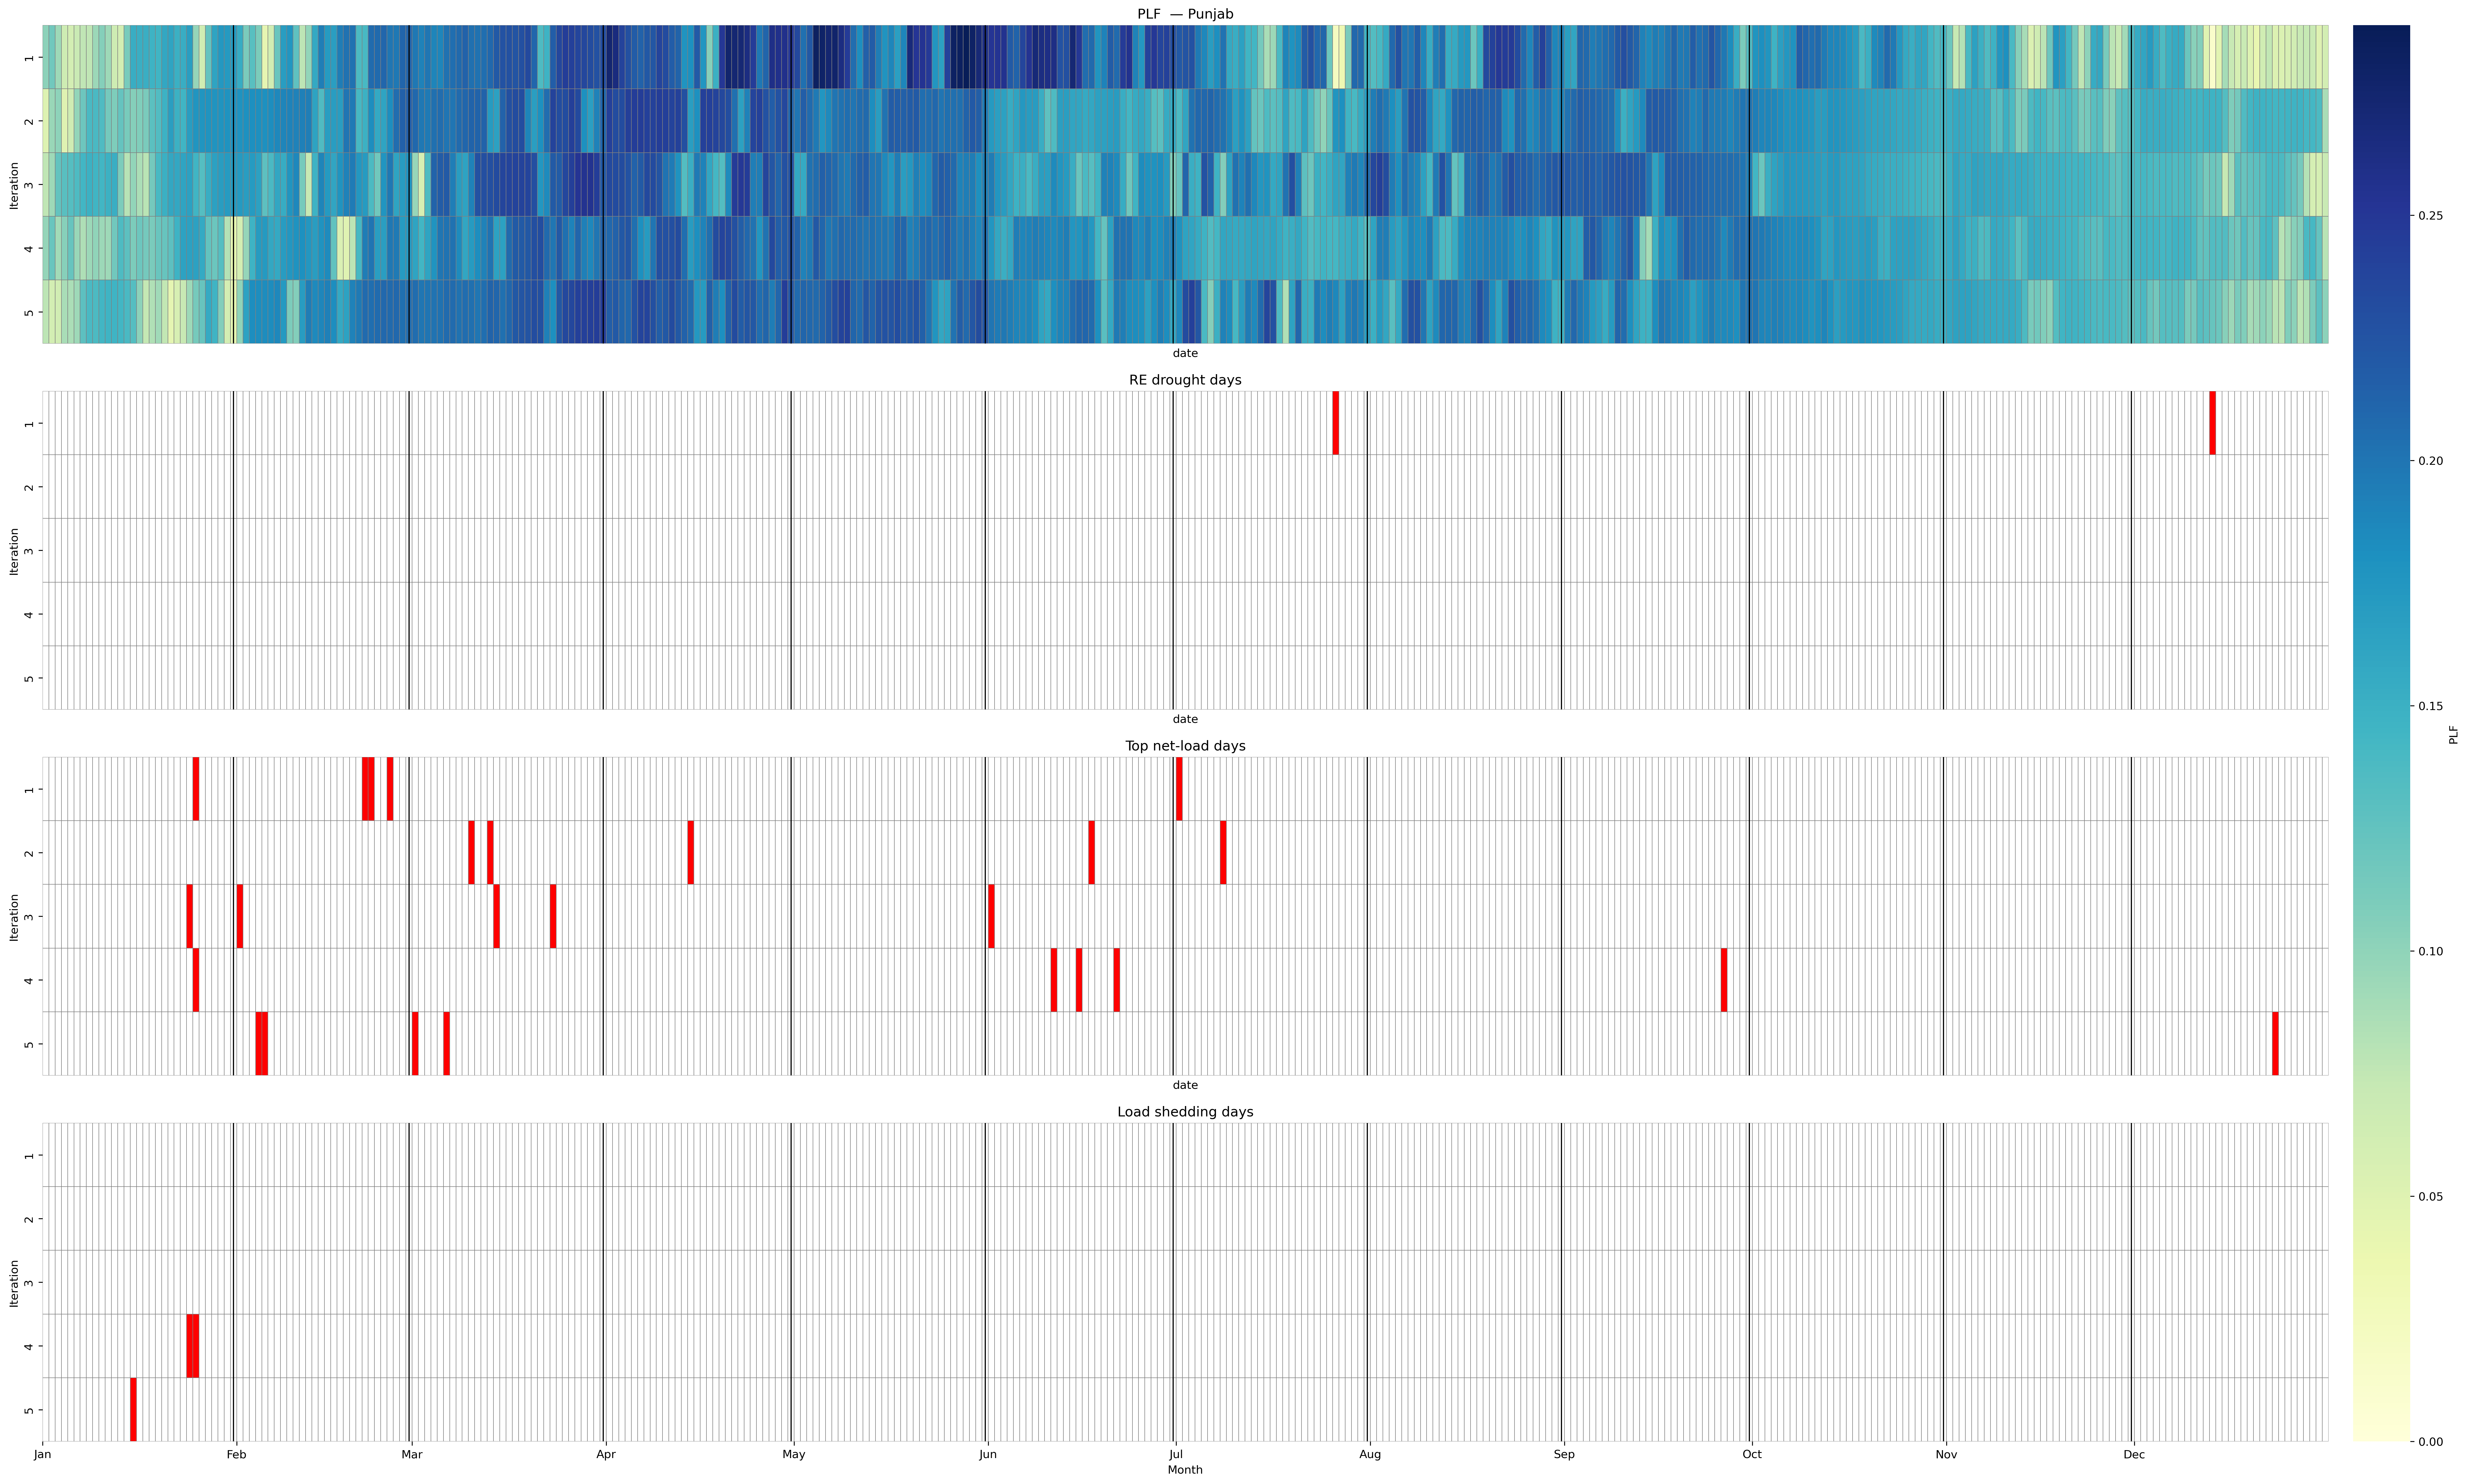

In [ ]:
# --- choose your zone and binning ---
selected_zone = "Punjab"
freq = "D"   # keep daily; x-axis will show month names

# require the net_load & load_shedding flag columns
for col in ['net_load', 'load_shedding']:
    if col not in plf_df.columns:
        raise ValueError(f"plf_df must have a '{col}' column (0/1) before plotting.")

# 1) Filter + prep
z = plf_df.loc[
    plf_df['load_zone'] == selected_zone,
    ['W','H','A','date','plf','low_plf_flag','net_load','load_shedding']
].copy()
z['date'] = pd.to_datetime(z['date'])

# 2) Iteration numbers
iters = z[['W','H','A']].drop_duplicates().reset_index(drop=True)
iters['iteration'] = np.arange(1, len(iters)+1)
z = z.merge(iters, on=['W','H','A'], how='left')

# 3) Matrices (resampled to your freq)
heat = z.pivot_table(index='iteration', columns='date', values='plf',            aggfunc='mean').T.resample(freq).mean().T
flag = z.pivot_table(index='iteration', columns='date', values='low_plf_flag',   aggfunc='max' ).T.resample(freq).max().T
net  = z.pivot_table(index='iteration', columns='date', values='net_load',       aggfunc='max' ).T.resample(freq).max().T
shed = z.pivot_table(index='iteration', columns='date', values='load_shedding',  aggfunc='max' ).T.resample(freq).max().T

# Align rows & columns
flag = flag.reindex(index=heat.index, columns=heat.columns)
net  = net .reindex(index=heat.index, columns=heat.columns)
shed = shed.reindex(index=heat.index, columns=heat.columns)

# --- rotate columns so the x-axis starts at January (if present) ---
cols_dt = pd.to_datetime(heat.columns)
jan_idx = np.where(cols_dt.month == 1)[0]
if len(jan_idx) > 0:
    start = jan_idx[0]
    order = np.r_[start:len(cols_dt), 0:start]
    heat  = heat.iloc[:, order]
    flag  = flag.iloc[:, order]
    net   = net .iloc[:, order]
    shed  = shed.iloc[:, order]
    cols_dt = cols_dt[order]

# Month tick positions + labels (after rotation)
p = cols_dt.to_period('M')
month_starts = np.r_[0, np.where(p[1:] != p[:-1])[0] + 1]
month_labels = cols_dt[month_starts].strftime('%b')

# --- layout: four equal plots + a dedicated colorbar axis ---
fig = plt.figure(figsize=(min(30, 2 + 0.4*heat.shape[1]), max(6, 0.5*heat.shape[0]) * 3.0),
                 dpi=300, constrained_layout=True)
gs  = fig.add_gridspec(nrows=4, ncols=2, width_ratios=[40, 1], height_ratios=[1, 1, 1, 1])

ax_top   = fig.add_subplot(gs[0, 0])   # PLF
ax_mid1  = fig.add_subplot(gs[1, 0])   # RE drought flag
ax_mid2  = fig.add_subplot(gs[2, 0])   # Top net-load flag
ax_bot   = fig.add_subplot(gs[3, 0])   # Load shedding flag
cax      = fig.add_subplot(gs[:, 1])

# Top: PLF heatmap (0 → max)
vmax = np.nanmax(heat.values) if np.isfinite(np.nanmax(heat.values)) else 1.0
sns.heatmap(
    heat, ax=ax_top,
    cmap="YlGnBu", vmin=0, vmax=vmax,
    linewidths=0.1, linecolor="grey",
    cbar=True, cbar_ax=cax
)
ax_top.set_title(f"PLF  — {selected_zone}")
ax_top.set_ylabel("Iteration")
ax_top.set_xticks([])

# Middle 1: low_plf_flag (white=0, red=1)
sns.heatmap(
    flag, ax=ax_mid1,
    cmap=ListedColormap(['white', 'red']), vmin=0, vmax=1,
    linewidths=0.1, linecolor="gray",
    cbar=False
)
ax_mid1.set_title("RE drought days")
ax_mid1.set_ylabel("Iteration")
ax_mid1.set_xticks([])

# Middle 2: top net-load days (white=0, red=1)
sns.heatmap(
    net, ax=ax_mid2,
    cmap=ListedColormap(['white', 'red']), vmin=0, vmax=1,
    linewidths=0.1, linecolor="gray",
    cbar=False
)
ax_mid2.set_title("Top net-load days")
ax_mid2.set_ylabel("Iteration")
ax_mid2.set_xticks([])

# Bottom: load shedding days (white=0, red=1)
sns.heatmap(
    shed, ax=ax_bot,
    cmap=ListedColormap(['white', 'red']), vmin=0, vmax=1,
    linewidths=0.1, linecolor="gray",
    cbar=False
)
ax_bot.set_title("Load shedding days")
ax_bot.set_ylabel("Iteration")

# X-axis: month names only, starting at January (only on bottom axis)
ax_bot.set_xticks(month_starts)
ax_bot.set_xticklabels(month_labels, rotation=0)
ax_bot.set_xlabel("Month")

# Dark separators at month boundaries on ALL plots
for ax in (ax_top, ax_mid1, ax_mid2, ax_bot):
    for x in month_starts[1:]:  # skip the first start
        ax.axvline(x - 0.5, color='black', linewidth=1.0)

# Colorbar label
cax.set_ylabel("PLF")

# save this plot
plt.savefig(path_to_save_images +f"renew_energy_drought_{selected_zone}.png", 
            bbox_inches = 'tight',
            dpi = 300)

plt.show()


# Undergeneration and overgeneration heatmap

In [28]:
df_overgen = df_dispatch_.copy()
df_overgen = df_overgen[['timestamp','load_zone','curtailment_mw']]
df_overgen = df_overgen.groupby(['timestamp']).agg({'curtailment_mw': 'mean'}).reset_index(drop = False)

df_load_shedding = df_load_.copy()
df_load_shedding = df_load_shedding[['timestamp','load_zone','unserved_energy']]
df_load_shedding = df_load_shedding.groupby(['timestamp']).agg({'unserved_energy': 'sum'}).reset_index(drop = False)

df_overgen_final = pd.merge(df_overgen, df_load_shedding, on = 'timestamp', how = 'outer')
df_overgen_final['residual'] = df_overgen_final['curtailment_mw'] - df_overgen_final['unserved_energy']

In [29]:
# df_overgen_final['residual'] = df_overgen_final['curtailment_mw'] - df_overgen_final['unserved_energy']

# # Extract month and hour
# df_overgen_final['month'] = df_overgen_final['timestamp'].dt.month
# df_overgen_final['hour']  = df_overgen_final['timestamp'].dt.hour + 1  # to get 1–24

# # Build pivot table: sum of residuals by hour (rows) and month (columns)
# pivot_table = df_overgen_final.pivot_table(
#     values='residual',
#     index='hour',
#     columns='month',
#     aggfunc='sum'
# )


# # Determine max absolute residual for symmetric color scaling
# max_abs = np.abs(pivot_table.values).max()

# # Plot heatmap
# plt.figure(figsize=(12, 8))
# sns.heatmap(
#     pivot_table,
#     cmap='RdBu_r',    # reversed so negatives = red, positives = blue
#     center=0,         # zero maps to white
#     vmin=-max_abs,    # symmetric around zero
#     vmax= max_abs,
#     annot=False,
#     fmt=".1f"
# )

# # Labels and titles
# plt.xlabel('Month', fontsize=14)
# plt.ylabel('Hour of the Day', fontsize=14)
# plt.title('Heatmap of Residual (Curtailment − Unserved Energy)', fontsize=16)

# # Set month abbreviations on x-axis
# plt.xticks(
#     ticks=np.arange(0.5, 12.5),
#     labels=[calendar.month_abbr[i] for i in range(1, 13)],
#     rotation=45
# )
# plt.yticks(fontsize = 10)

# plt.tight_layout()
# plt.show()

nan nan


ValueError: cannot convert float NaN to integer

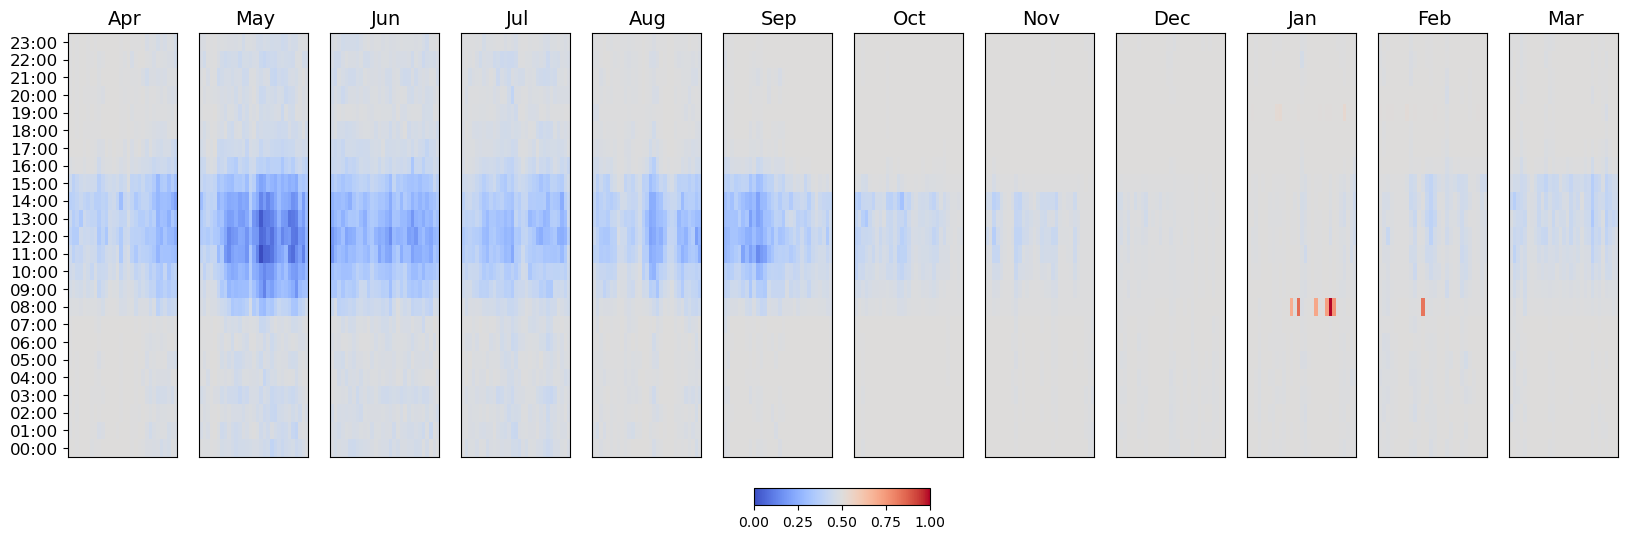

In [30]:
def _expected_unserved_energy(ax_, EUE_, EOE_): 

    units = 1e3

    N_years = 18
    N_hours = 24
    N_days  = 365

    month_days_     = np.array([0, 30, 31, 30, 31, 31, 30, 31, 30, 31, 31, 28, 31])
    months_         = ['Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar']
    cum_month_days_ = np.cumsum(month_days_)
    
    EUE_ = np.stack([EUE_[i*N_hours:(i + 1)*N_hours] for i in range(N_days)])
    EOE_ = np.stack([EOE_[i*N_hours:(i + 1)*N_hours] for i in range(N_days)])
    EUE_ = (EOE_ - EUE_)/units
    print(EUE_.min(), EUE_.max())

    idx_under_ = EUE_ > 0
    idx_over_  = EUE_ <= 0
    norm_EUE_ = np.zeros(EUE_.shape)

    norm_EUE_[idx_under_] = EUE_[idx_under_]/EUE_[idx_under_].max()
    norm_EUE_[idx_over_]  = -EUE_[idx_over_]/EUE_[idx_over_].min()

    hours_ = np.arange(datetime(2036, 1, 1, 0), datetime(2036, 1, 2, 0), timedelta(days = 1/24)).astype(datetime)
    hours_ = pd.to_datetime(hours_).strftime('%H:%M')

    _cmap = sns.color_palette("coolwarm", as_cmap=True)

    for i in range(12):
        ax_[i].imshow(norm_EUE_[cum_month_days_[i]:cum_month_days_[i + 1], :].T, 
                      origin        = 'lower', 
                      vmin          = -1.,
                      vmax          = 1,
                      aspect        = 'auto', 
                      cmap          = _cmap,
                      interpolation = 'None')
        
        ax_[i].set_xticks([month_days_[i + 1]/2], [months_[i]], fontsize = 14)
        ax_[i].tick_params(axis = "x", length = 0)
        ax_[i].set_yticks([], [])
        ax_[i].xaxis.tick_top()

    ax_[0].set_yticks(np.linspace(0, 23, 24), hours_, fontsize = 12)

    cbar = fig.colorbar(cm.ScalarMappable(cmap = _cmap), 
                        cax = ax_[5].inset_axes([-215, -3.25, 50., 1.], transform = ax_[-1].transData), 
                        orientation = 'horizontal')

    cbar.set_ticks([0, 1], labels = [f'{-int(EUE_.max())} (GWh)', f'{-int(EUE_.min())} (GWh)'], size = 10)
    
    #cbar.ax.tick_params(length = 0)
    cbar.ax.set_title('Curtailment/Unserved Energy', rotation = 0, size = 12)
    

Shed_    = df_overgen_final['curtailment_mw'].to_numpy()
Curtail_ = df_overgen_final['unserved_energy'].to_numpy()

fig_, ax_ = plt.subplots(figsize = (20, 5.5), 
                         nrows = 1,
                         ncols = 12)

_expected_unserved_energy(ax_, Shed_, Curtail_)

plt.savefig(path_to_save_images + '/national-level_overundergen_heatmap.png', 
            bbox_inches = 'tight', 
            dpi = 600)

plt.savefig(path_to_save_images + '/national-level_overundergen_heatmap.pdf', 
            bbox_inches = 'tight', 
            dpi = 600)

plt.show() 

In [34]:

plf_threshold = 0.025    # your existing low PLF cut
k_consec      = 2        # drought = >=k consecutive low-PLF days

# -----------------------------
# 1) Build a clean daily master
# -----------------------------
# Base: from plf_df
base = plf_df.copy()
base['date'] = pd.to_datetime(base['date']).dt.normalize()
for c in ['load_zone','W','H','A']:
    base[c] = base[c].astype(str)

# Daily net load (peak & sum) from netload_df
nl = netload_df.copy()
nl['timestamp'] = pd.to_datetime(nl['timestamp'])
nl['date'] = nl['timestamp'].dt.normalize()
for c in ['load_zone','W','H','A']:
    nl[c] = nl[c].astype(str)

daily_netload = (
    nl.groupby(['load_zone','W','H','A','date'], as_index=False)['net_load_mw']
      .agg(daily_peak_netload_mw='max', daily_netload_mwh='sum')   # 1h steps → sum(MW)=MWh
)

# Daily unserved energy & flag from df_load_
ls = df_load_.copy()
if 'timestamp' not in ls.columns:
    tp = ls['timepoint'].astype(str)
    d  = pd.to_datetime(tp.str[:8], format='%Y%m%d')
    h  = tp.str[8:].astype(int)  # 1..24
    ls['timestamp'] = d + pd.to_timedelta(h - 1, 'h')

ls['date'] = ls['timestamp'].dt.normalize()
for c in ['load_zone','W','H','A']:
    ls[c] = ls[c].astype(str)

ls_daily = (
    ls.groupby(['load_zone','W','H','A','date'], as_index=False)['unserved_energy']
      .sum()
      .rename(columns={'unserved_energy':'load_shedding_mwh'})
)
ls_daily['load_shedding_flag'] = (ls_daily['load_shedding_mwh'] > 0).astype('int8')

# Merge all into one daily table
daily = (base[['load_zone','W','H','A','date','plf','low_plf_flag','net_load','load_shedding']]
         .merge(daily_netload, on=['load_zone','W','H','A','date'], how='left')
         .merge(ls_daily,     on=['load_zone','W','H','A','date'], how='left'))

# Fill safe defaults
daily[['daily_peak_netload_mw','daily_netload_mwh','load_shedding_mwh']] = \
    daily[['daily_peak_netload_mw','daily_netload_mwh','load_shedding_mwh']].fillna(0)
daily['load_shedding_flag'] = daily['load_shedding_flag'].fillna(0).astype('int8')

# -----------------------------
# 2) Drought definition: >=k consecutive low-PLF days (per zone, W,H,A)
# -----------------------------
daily = daily.sort_values(['load_zone','W','H','A','date']).reset_index(drop=True)

def consec_flag(s, k):
    # rolling count of low-PLF days; mark 1 if current and previous k-1 are low
    return (s.rolling(window=k, min_periods=k).sum() >= k).astype('int8')

daily['drought_k'] = (
    daily.groupby(['load_zone','W','H','A'])['low_plf_flag']
         .transform(lambda x: consec_flag(x, k_consec))
)

# -----------------------------
# 3) Expected EUE (per zone, W,H,A) & ratios
# -----------------------------
# Expected EUE over the analysis window
expected_eue = (daily.groupby(['load_zone','W','H','A'], as_index=False)['load_shedding_mwh']
                      .sum()
                      .rename(columns={'load_shedding_mwh':'expected_eue_mwh'}))

daily = daily.merge(expected_eue, on=['load_zone','W','H','A'], how='left')
daily['expected_eue_mwh'] = daily['expected_eue_mwh'].fillna(0)

# Ratio: daily EUE as share of expected EUE
daily['load_shedding_eue'] = np.where(
    daily['expected_eue_mwh'] > 0,
    daily['load_shedding_mwh'] / daily['expected_eue_mwh'],
    np.nan
)

# -----------------------------
# 4) Ratio to “top net load” reference
# -----------------------------
# Define per-combo max of the top-5 daily peaks (your earlier convention)
top5_max = (daily.sort_values(['load_zone','W','H','A','daily_peak_netload_mw'], ascending=[True,True,True,True,False])
                 .groupby(['load_zone','W','H','A'], as_index=False).head(5)
                 .groupby(['load_zone','W','H','A'], as_index=False)['daily_peak_netload_mw']
                 .max()
                 .rename(columns={'daily_peak_netload_mw':'top_netload_max_mw'}))

daily = daily.merge(top5_max, on=['load_zone','W','H','A'], how='left')
daily['load_shedding_top_net_load'] = np.where(
    daily['top_netload_max_mw'] > 0,
    daily['load_shedding_mwh'] / daily['top_netload_max_mw'],
    np.nan
)


# A) Enrichment: share of top net-load days that are drought vs baseline drought rate
top_net = daily[daily['net_load'] == 1]
baseline_drought_rate = daily['drought_k'].mean()
enriched_share = top_net['drought_k'].mean() if not top_net.empty else np.nan

# B) Net-load uplift on drought days
uplift = (daily.groupby('drought_k')['daily_peak_netload_mw'].mean()
                .rename({0:'non_drought_mean_mw', 1:'drought_mean_mw'}))
uplift_diff = uplift.get('drought_mean_mw', np.nan) - uplift.get('non_drought_mean_mw', np.nan)

# C) Loss-of-load risk ratio
p_ls_drought    = daily.loc[daily['drought_k']==1, 'load_shedding_flag'].mean() if (daily['drought_k']==1).any() else np.nan
p_ls_non        = daily.loc[daily['drought_k']==0, 'load_shedding_flag'].mean() if (daily['drought_k']==0).any() else np.nan
risk_ratio_ls   = (p_ls_drought / p_ls_non) if (p_ls_drought==p_ls_drought and p_ls_non and p_ls_non>0) else np.nan

# D) Share of EUE occurring during droughts
share_eue_drought = (daily.loc[daily['drought_k']==1, 'load_shedding_mwh'].sum() /
                     daily['load_shedding_mwh'].sum()) if daily['load_shedding_mwh'].sum()>0 else np.nan


print(f"Baseline drought rate (all days): {baseline_drought_rate:.2%}")
print(f"Share of TOP net-load days in drought: {enriched_share:.2%}")
print(f"Net-load uplift (drought − non): {uplift_diff:.1f} MW")
print(f"Loss-of-load risk ratio (drought vs non): {risk_ratio_ls:.2f}")
print(f"Share of EUE in drought days: {share_eue_drought:.2%}")




Baseline drought rate (all days): 1.76%
Share of TOP net-load days in drought: 1.88%
Net-load uplift (drought − non): -11429.3 MW
Loss-of-load risk ratio (drought vs non): 0.00
Share of EUE in drought days: 0.00%


In [ ]:

k_consec = 2   # drought = >= k consecutive low-PLF days

# =====================
# 0) DAILY MASTER (per load_zone, W, H, A)
# =====================
# Start from plf_df (already has: plf, low_plf_flag, net_load, load_shedding)
daily = plf_df.copy()
daily['date'] = pd.to_datetime(daily['date']).dt.normalize()
for c in ['load_zone','W','H','A']:
    daily[c] = daily[c].astype(str)

# Daily net load (peak + energy) from netload_df
nl = netload_df.copy()
nl['timestamp'] = pd.to_datetime(nl['timestamp'])
nl['date'] = nl['timestamp'].dt.normalize()
for c in ['load_zone','W','H','A']:
    nl[c] = nl[c].astype(str)

daily_netload = (
    nl.groupby(['load_zone','W','H','A','date'], as_index=False)['net_load_mw']
      .agg(daily_peak_netload_mw='max', daily_netload_mwh='sum')  # 1h steps → sum(MW)=MWh
)

# Daily unserved energy from df_load_
ls = df_load_.copy()
if 'timestamp' not in ls.columns:
    tp = ls['timepoint'].astype(str)
    d  = pd.to_datetime(tp.str[:8], format='%Y%m%d')
    h  = tp.str[8:].astype(int)  # 1..24
    ls['timestamp'] = d + pd.to_timedelta(h - 1, 'h')

ls['date'] = ls['timestamp'].dt.normalize()
for c in ['load_zone','W','H','A']:
    ls[c] = ls[c].astype(str)

ls_daily = (
    ls.groupby(['load_zone','W','H','A','date'], as_index=False)['unserved_energy']
      .sum()
      .rename(columns={'unserved_energy':'load_shedding_mwh'})
)
ls_daily['load_shedding_flag'] = (ls_daily['load_shedding_mwh'] > 0).astype('int8')

# Merge into one daily table (per zone, W, H, A, date)
daily = (daily
         .merge(daily_netload, on=['load_zone','W','H','A','date'], how='left')
         .merge(ls_daily,     on=['load_zone','W','H','A','date'], how='left'))

# Fill safe defaults
daily[['daily_peak_netload_mw','daily_netload_mwh','load_shedding_mwh']] = \
    daily[['daily_peak_netload_mw','daily_netload_mwh','load_shedding_mwh']].fillna(0)
daily['load_shedding_flag'] = daily['load_shedding_flag'].fillna(0).astype('int8')

# =====================
# 1) DROUGHT FLAG (>= k consecutive low-PLF days) per combo
# =====================
daily = daily.sort_values(['load_zone','W','H','A','date']).reset_index(drop=True)

def consec_flag(s, k):
    # marks 1 when the current day and previous k-1 days are low-PLF
    return (s.rolling(window=k, min_periods=k).sum() >= k).astype('int8')

daily['drought_k'] = (
    daily.groupby(['load_zone','W','H','A'])['low_plf_flag']
         .transform(lambda x: consec_flag(x, k_consec))
)

# =====================
# 2) EXPECTED EUE per combo + daily ratio columns
# =====================
# Expected EUE over the (filtered) window per combo
expected_eue = (daily.groupby(['load_zone','W','H','A'], as_index=False)['load_shedding_mwh']
                      .sum()
                      .rename(columns={'load_shedding_mwh':'expected_eue_mwh'}))

daily = daily.merge(expected_eue, on=['load_zone','W','H','A'], how='left')
daily['expected_eue_mwh'] = daily['expected_eue_mwh'].fillna(0)

# Ratio: daily EUE as share of expected EUE
daily['load_shedding_eue'] = np.where(
    daily['expected_eue_mwh'] > 0,
    daily['load_shedding_mwh'] / daily['expected_eue_mwh'],
    np.nan
)

# Max of TOP-5 daily peak net load per combo (denominator for your 3rd column)
top5_max = (daily.sort_values(['load_zone','W','H','A','daily_peak_netload_mw'],
                              ascending=[True,True,True,True,False])
                 .groupby(['load_zone','W','H','A'], as_index=False).head(5)
                 .groupby(['load_zone','W','H','A'], as_index=False)['daily_peak_netload_mw']
                 .max()
                 .rename(columns={'daily_peak_netload_mw':'top_netload_max_mw'}))

daily = daily.merge(top5_max, on=['load_zone','W','H','A'], how='left')

# Ratio: daily EUE relative to top net load (MW)
daily['load_shedding_top_net_load'] = np.where(
    daily['top_netload_max_mw'] > 0,
    daily['load_shedding_mwh'] / daily['top_netload_max_mw'],
    np.nan
)

# =====================
# 3) PER-(load_zone, W, H, A) SUMMARY (research-style metrics)
# =====================
def summarize_combo(g):
    n_days = len(g)
    # baseline drought frequency
    baseline = g['drought_k'].mean()
    # share of TOP net-load days (net_load=1) that are drought days
    top = g[g['net_load']==1]
    enriched = top['drought_k'].mean() if len(top) else np.nan
    # net-load uplift during drought
    means = g.groupby('drought_k')['daily_peak_netload_mw'].mean()
    uplift = means.get(1, np.nan) - means.get(0, np.nan)
    # loss-of-load risk ratio
    p_d = g.loc[g['drought_k']==1, 'load_shedding_flag'].mean() if (g['drought_k']==1).any() else np.nan
    p_n = g.loc[g['drought_k']==0, 'load_shedding_flag'].mean() if (g['drought_k']==0).any() else np.nan
    rr  = (p_d / p_n) if (p_n and p_n>0) else np.nan
    # share of EUE during drought days
    eue_total = g['load_shedding_mwh'].sum()
    share_eue = (g.loc[g['drought_k']==1, 'load_shedding_mwh'].sum() / eue_total) if eue_total>0 else np.nan
    # denominators (helpful context)
    expected_eue = g['expected_eue_mwh'].iloc[0] if 'expected_eue_mwh' in g else np.nan
    top5_max = g['top_netload_max_mw'].iloc[0] if 'top_netload_max_mw' in g else np.nan

    return pd.Series({
        'n_days': n_days,
        'baseline_drought_rate': baseline,
        'enriched_share_top_netload': enriched,
        'netload_uplift_mw': uplift,
        'loss_shedding_risk_ratio': rr,
        'share_EUE_in_drought': share_eue,
        'expected_eue_mwh': expected_eue,
        'top_netload_max_mw': top5_max,
    })

summary_by_combo = (daily
    .groupby(['load_zone','W','H','A'], as_index=False)
    .apply(lambda g: summarize_combo(g))
    .reset_index(drop=True)
)

# =====================
# OUTPUTS
# =====================
# daily: per-day analysis with drought_k, expected_eue_mwh, load_shedding_eue,
#        top_netload_max_mw, load_shedding_top_net_load (all per load_zone,W,H,A)
# summary_by_combo: one row per (load_zone, W, H, A) with research metrics


/tmp/ipykernel_1528439/1268839572.py:137: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary_by_combo = (daily
